# Signal Preprocessing

[Classification of ECG Using Ensemble of Residual CNNs with Attention Mechanism](https://ieeexplore.ieee.org/document/9662723)

1. Provided data are expanded into fixed 12-lead configuration. If any lead is missing, the particular matrix row is filled with zeroes. This transformation always outputs a matrix with dimensions (12, time).
2. Resampling: Data are resampled to the sampling frequency of 500 Hz. Polyphase filtering is used when the original sampling frequency is 1000 Hz; otherwise, the FFT method is used for resampling.
3. Filtering: Data are filtered using a zero-phase method with 3rd order Butterworth bandpass filter with frequency band from 1 Hz to 47 Hz.
4. Normalization: Each ECG channel is normalized using a z-score.
5. Zeropadding: Data are zero-padded into the shape of 8192 samples in the time domain. If a signal length is larger than 8192, then the signal is randomly sampled and
cut into the length of 8192.
6. Augmentation: During the training phase, randomly choose the lead configuration (e.g. 12, 6, 4, 3, 2). Leads that are not used are filled with zeros.

In [6]:
import os

import wfdb
from scipy import signal
from scipy.stats import zscore
import matplotlib.pyplot as plt

In [7]:
os.chdir('..')

In [20]:
sig = wfdb.rdrecord('cinc-2021_data/training/cpsc_2018/g4/A3034')
sig_pulse_raw = sig.p_signal[:,0][:600]

print(f"frequency: {sig.fs} Hz")

frequency: 500 Hz


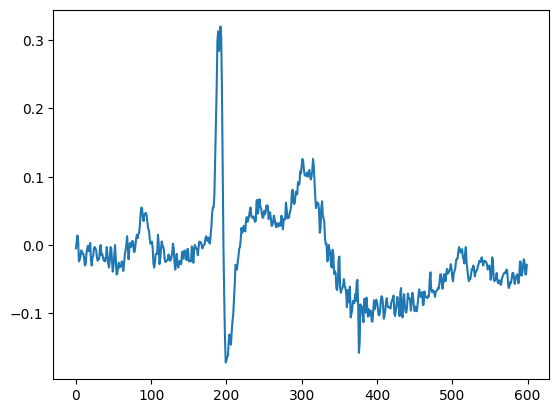

In [21]:
plt.plot(sig_pulse_raw)

## Butterworth bandpass filter

- Order: 3
- Bandpass Range: 1 Hz ... 47 Hz
- Sample Rate: 500 Hz

In [28]:
b, a = signal.butter(3, [1 / 250, 47 / 250], 'bandpass')
sig_pulse_butter = signal.filtfilt(b, a, sig_pulse_raw)

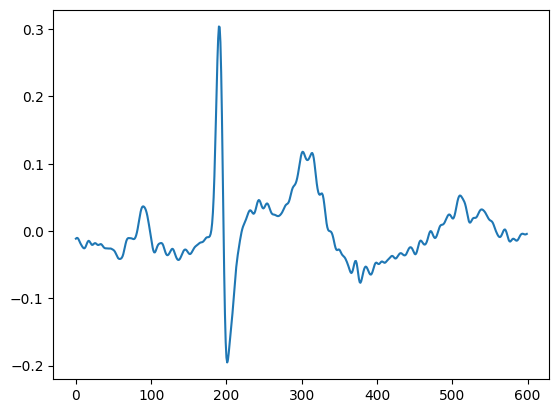

In [23]:
plt.plot(sig_pulse_butter)

In [24]:
sig_pulse_zscore = zscore(sig_pulse_butter, axis=-1)

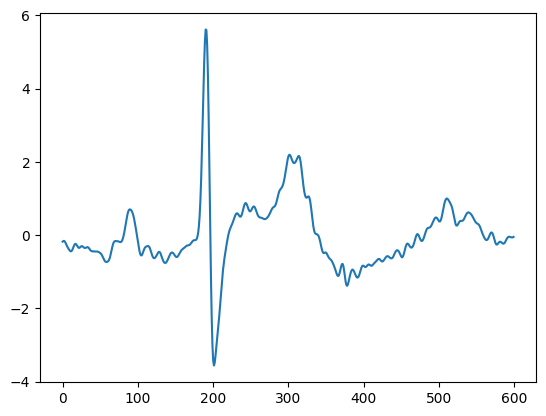

In [25]:
plt.plot(sig_pulse_zscore)

In [ ]:
# source: Classification of ECG Using Ensemble of Residual CNNs with Attention Mechanism
def preprocessing(recording,leads,fs):
    b,a = signal.butter(3, [1 / 250, 47 / 250], 'bandpass')

    if fs==1000:
        recording = signal.resample_poly(recording, up=1, down=2, axis=-1) # to 500Hz
        fs = 500
    elif fs==500:
        pass
    else:
        recording = signal.resample(recording, int(recording.shape[1] * 500 / fs), axis=1)
        print(f'RESAMPLING FROM {fs} TO 500')
        fs = 500



    recording = signal.filtfilt(b, a, recording)
    recording = zscore(recording, axis=-1)
    recording = np.nan_to_num(recording)
    recording = zeropad(recording)
    recording = torch.from_numpy(recording).view(1,12,1,-1).float().to(DEVICE)
    leads = torch.from_numpy(leads).float().view(1,12).to(DEVICE)
    return recording,leads